# Задание 3. Моделирование ТДС после имплантации частиц

## Постановка задачи

Рассматривается одномерный образец вольфрама толщиной 20 мкм.  
Модель учитывает диффузию подвижного водорода, захват и выход из двух типов ловушек.

Водород имплантируется в приповерхностную область в соответствии с гауссовым профилем. На обеих поверхностях задаётся нулевая концентрация подвижного водорода, что соответствует его мгновенному удалению с поверхности. Начальные концентрации всех частиц равны нулю.

Расчёт включает три этапа:

1. **Имплантация, 0–400 с:** источник включён, температура равна 300 К.
2. **Выдержка, 400–450 с:** источник выключен, температура остаётся равной 300 К.
3. **ТДС, 450–500 с:** источник выключен, температура увеличивается со скоростью 8 К/с.

Рассчитываются профили подвижного и захваченного водорода, количество водорода в ловушках и суммарный поток десорбции через обе поверхности.


In [2]:
import festim as F
import numpy as np
import ufl
import matplotlib.pyplot as plt

model = F.HydrogenTransportProblem()

vertices = np.concatenate(
    [
        np.linspace(0.0, 30e-9, num=200, endpoint=False),
        np.linspace(30e-9, 3e-6, num=300, endpoint=False),
        np.linspace(3e-6, 20e-6, num=200),
    ]
)
model.mesh = F.Mesh1D(vertices)


## Материал, частицы и ловушки


In [3]:
tungsten = F.Material(
    D_0=4.1e-7,
    E_D=0.39,
)

volume = F.VolumeSubdomain1D(
    id=1,
    borders=[0.0, 20e-6],
    material=tungsten,
)
left = F.SurfaceSubdomain1D(id=1, x=0.0)
right = F.SurfaceSubdomain1D(id=2, x=20e-6)

model.subdomains = [volume, left, right]

avogadro = 6.02214076e23
w_atom_density = 6.3e28 / avogadro

H = F.Species("H")
trapped_H1 = F.Species("trapped_H1", mobile=False)
trapped_H2 = F.Species("trapped_H2", mobile=False)

empty_trap1 = F.ImplicitSpecies(
    n=1.3e-3 * w_atom_density,
    others=[trapped_H1],
)
empty_trap2 = F.ImplicitSpecies(
    n=4e-4 * w_atom_density,
    others=[trapped_H2],
)

model.species = [H, trapped_H1, trapped_H2]

capture_prefactor = (
    4.1e-7
    / (1.1e-10**2 * 6 * w_atom_density)
)

reaction_1 = F.Reaction(
    reactant=[H, empty_trap1],
    product=[trapped_H1],
    k_0=capture_prefactor,
    E_k=0.39,
    p_0=1e13,
    E_p=0.87,
    volume=volume,
)

reaction_2 = F.Reaction(
    reactant=[H, empty_trap2],
    product=[trapped_H2],
    k_0=capture_prefactor,
    E_k=0.39,
    p_0=1e13,
    E_p=1.0,
    volume=volume,
)

model.reactions = [reaction_1, reaction_2]


## Имплантация

Источник задаётся как произведение потока частиц и гауссова профиля:

$$
S(x,t)=\varphi(t)f(x).
$$


In [4]:
implantation_time = 400.0
incident_flux = 2.5e19 / avogadro


def ion_flux(t):
    return ufl.conditional(
        t <= implantation_time,
        incident_flux,
        0.0,
    )


def gaussian_distribution(x, center, width):
    return (
        1.0
        / (width * np.sqrt(2.0 * np.pi))
        * ufl.exp(
            -0.5
            * ((x[0] - center) / width) ** 2
        )
    )


source = F.ParticleSource(
    value=lambda x, t: (
        ion_flux(t)
        * gaussian_distribution(
            x,
            center=4.5e-9,
            width=2.5e-9,
        )
    ),
    volume=volume,
    species=H,
)

model.sources = [source]

model.boundary_conditions = [
    F.FixedConcentrationBC(
        subdomain=left,
        value=0.0,
        species=H,
    ),
    F.FixedConcentrationBC(
        subdomain=right,
        value=0.0,
        species=H,
    ),
]


## Температура и временной шаг

До начала ТДС температура равна 300 К. Затем она увеличивается со скоростью 8 К/с.


In [5]:
implantation_temperature = 300.0
heating_rate = 8.0
start_tds = implantation_time + 50.0


def temperature(t):
    if t <= start_tds:
        return implantation_temperature
    return (
        implantation_temperature
        + heating_rate * (t - start_tds)
    )


model.temperature = temperature

model.settings = F.Settings(
    atol=1e-10,
    rtol=1e-10,
    final_time=500.0,
    stepsize=F.Stepsize(
        initial_value=0.5,
        growth_factor=1.1,
        cutback_factor=0.9,
        target_nb_iterations=4,
        max_stepsize=(
            lambda t: 0.5
            if t > start_tds
            else None
        ),
        milestones=[
            implantation_time,
            start_tds,
            start_tds + 50.0,
        ],
    ),
)

## Экспорт


In [6]:
left_flux = F.SurfaceFlux(
    surface=left,
    field=H,
)
right_flux = F.SurfaceFlux(
    surface=right,
    field=H,
)

total_mobile_H = F.TotalVolume(
    field=H,
    volume=volume,
)
total_trapped_H1 = F.TotalVolume(
    field=trapped_H1,
    volume=volume,
)
total_trapped_H2 = F.TotalVolume(
    field=trapped_H2,
    volume=volume,
)

profile_exports = [
    F.Profile1DExport(
        field=species,
        times=[
            implantation_time,
            start_tds,
            start_tds + 50.0,
        ],
    )
    for species in [H, trapped_H1, trapped_H2]
]

model.exports = [
    total_mobile_H,
    total_trapped_H1,
    total_trapped_H2,
    left_flux,
    right_flux,
    *profile_exports,
]

model.initialise()
model.run()

Solving HydrogenTransportProblem:   0%|          | 0.00/500 [00:00<?, ?it/s]

## Профили концентраций


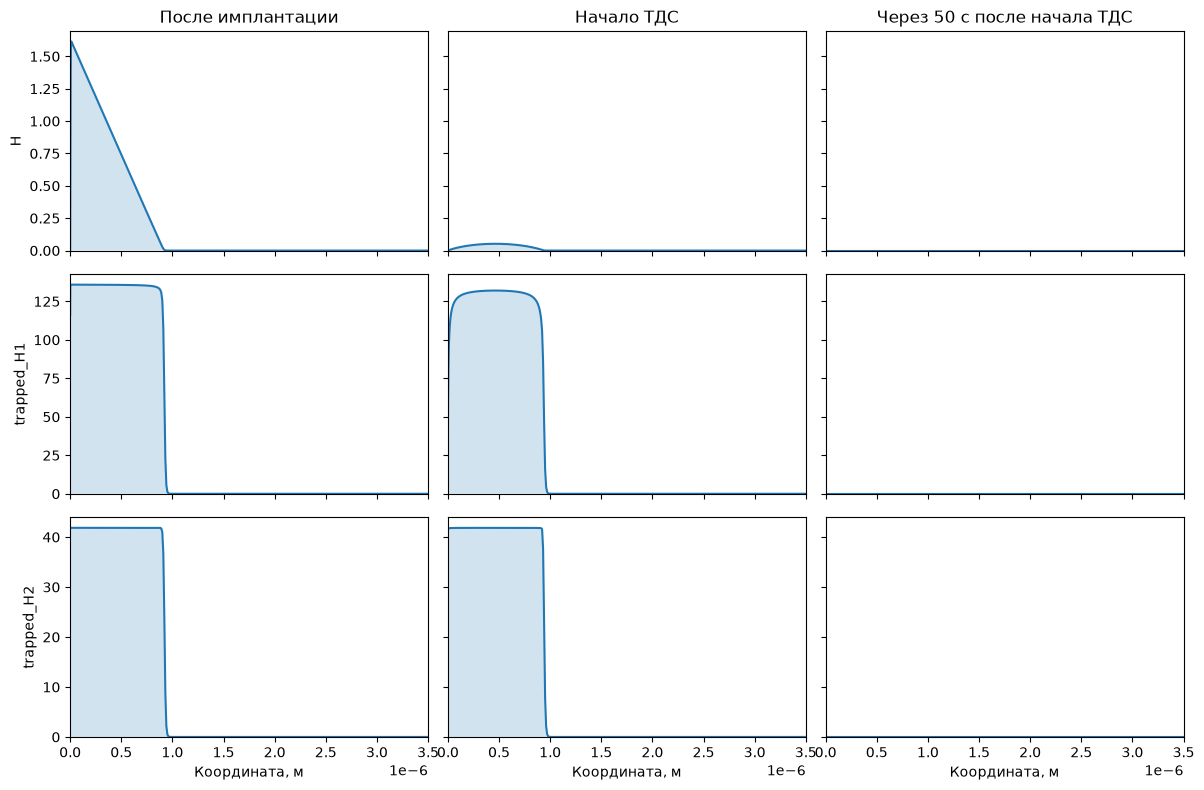

In [7]:
time_labels = [
    "После имплантации",
    "Начало ТДС",
    "Через 50 с после начала ТДС",
]

fig, axes = plt.subplots(
    3,
    3,
    sharex=True,
    sharey="row",
    figsize=(12, 8),
)

for row, profile in enumerate(profile_exports):
    axes[row, 0].set_ylabel(profile.field.name)

    for column, time in enumerate(profile.t):
        axes[0, column].set_title(
            time_labels[column]
        )
        axes[row, column].plot(
            profile.x,
            profile.data[column],
        )
        axes[row, column].fill_between(
            profile.x,
            profile.data[column],
            alpha=0.2,
        )

for axis in axes.flat:
    axis.set_ylim(bottom=0)

axes[2, 0].set_xlabel("Координата, м")
axes[2, 1].set_xlabel("Координата, м")
axes[2, 2].set_xlabel("Координата, м")
axes[0, 0].set_xlim(0.0, 3.5e-6)

plt.tight_layout()
plt.show()

## Спектр ТДС


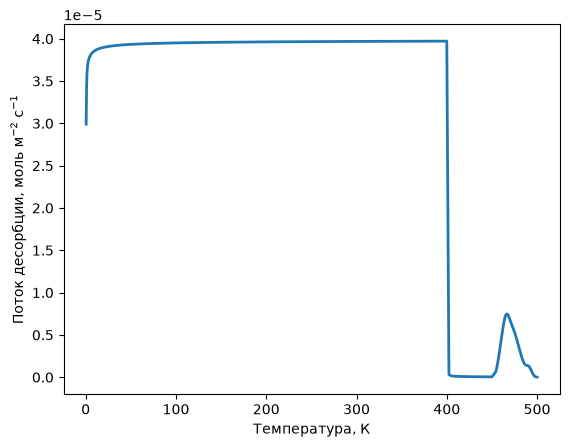

In [10]:
time = np.asarray(left_flux.t)
total_flux = (
    np.asarray(left_flux.data)
    + np.asarray(right_flux.data)
)

plt.plot(
    time,
    total_flux,
    linewidth=2,
)
plt.xlabel("Температура, К")
plt.ylabel(
    r"Поток десорбции, моль м$^{-2}$ с$^{-1}$"
)
plt.show()

## Вклад ловушек


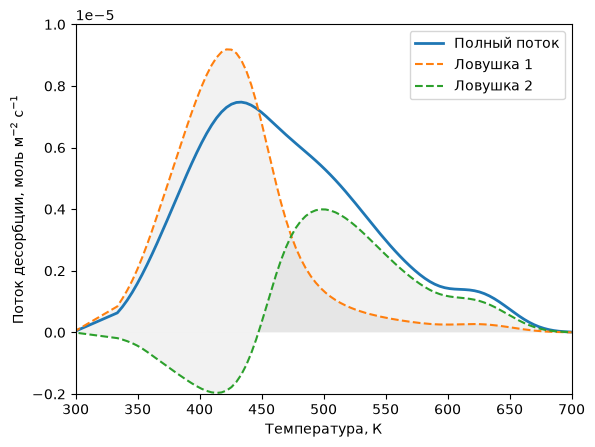

In [13]:
temperature_values = np.array(
    [temperature(t) for t in time]
)

trap_1_contribution = (
    -np.diff(total_trapped_H1.data)
    / np.diff(time)
)
trap_2_contribution = (
    -np.diff(total_trapped_H2.data)
    / np.diff(time)
)

plt.plot(
    temperature_values,
    total_flux,
    linewidth=2,
    label="Полный поток",
)
plt.plot(
    temperature_values[1:],
    trap_1_contribution,
    "--",
    label="Ловушка 1",
)
plt.fill_between(temperature_values[1:], 0, trap_1_contribution, facecolor="grey", alpha=0.1)

plt.plot(
    temperature_values[1:],
    trap_2_contribution,
    "--",
    label="Ловушка 2",
)
plt.fill_between(temperature_values[1:], 0, trap_2_contribution, facecolor="grey", alpha=0.1)

plt.xlim(
    temperature(start_tds),
    temperature(500.0),
)
plt.ylim(
    -0.2e-5,
    1e-5,
)
plt.xlabel("Температура, К")
plt.ylabel(
    r"Поток десорбции, моль м$^{-2}$ с$^{-1}$"
)
plt.legend()
plt.show()